In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving dataset.xlsx to dataset.xlsx


In [3]:
!pip install mibian

  Preparing metadata (setup.py) ... done
  Created wheel for mibian: filename=mibian-0.1.3-py3-none-any.whl size=4024 sha256=23753ce54b21f60644fac8ae5a3efba232065e392e2c0b34ea22f6d6466327e6
  Stored in directory: /root/.cache/pip/wheels/b2/71/71/a9ff30d4851199bf1efabdda83809623cf181762214ae6b7c7
Successfully built mibian


In [4]:
import numpy as np
import datetime
import mibian
import matplotlib.pyplot as plt
import warnings


def calculate_time_to_expiry(data):
    data.Expiry = pd.to_datetime(data.Expiry)
    data.Date = pd.to_datetime(data.Date)
    data['time_to_expiry'] = (data.Expiry - data.Date).dt.days
    return data

def atm_strike_price(options):
    options['strike_distance'] = np.abs(options.futures_price - options['Strike Price'])
    df = options.groupby(['Date'])['strike_distance'].min().to_frame()
    options = pd.merge(options, df)

    options = options[(np.abs(options.futures_price - options['Strike Price']) == options.strike_distance)]
    options = options.drop(columns=['strike_distance'])
    options = options.drop_duplicates(subset=['Date', 'Expiry', 'Option Type'])
    return options

def daily_pnl(options, full_opt):
    options = options.sort_values('Date').reset_index(drop=True)
    options['next_day_close'] = np.nan

    for i in range(len(options) - 1):
        trade_date = options.iloc[i]['Date']
        strike_price = options.iloc[i]['Strike Price']
        option_type = options.iloc[i]['Option Type']
        time_to_expiry = options.iloc[i]['time_to_expiry']

        future_dates = options[(options['Date'] > trade_date) &
                               (options['Date'] <= trade_date + datetime.timedelta(days=20))]

        if future_dates.empty:
            continue

        next_trading_date = future_dates.iloc[0]['Date']
        row_idx = options.index[i]

        if time_to_expiry != 0:
            match = full_opt[(full_opt['Strike Price'] == strike_price) &
                             (full_opt['Date'] == next_trading_date) &
                             (full_opt['Option Type'] == option_type)]
            if not match.empty:
                options.loc[row_idx, 'next_day_close'] = match.iloc[0]['Close']
        else:
            options.loc[row_idx, 'next_day_close'] = options.loc[row_idx, 'Close']

    options['daily_straddle_pnl'] = (options['next_day_close'] - options['Close'])
    return options

def implied_volatility_options(options):
    options['IV'] = np.nan
    options.loc[(options.time_to_expiry == 0), 'time_to_expiry'] = 0.0000001

    for i in range(len(options)):
        pricing_params = [options.iloc[i]['futures_price'], options.iloc[i]['Strike Price'], 0, options.iloc[i]['time_to_expiry']]

        if options.iloc[i]['Option Type'] == 'CALL':
            options.iloc[i, options.columns.get_loc('IV')] = mibian.BS(pricing_params, callPrice=options.iloc[i]['Close']).impliedVolatility
        elif options.iloc[i]['Option Type'] == 'PUTO':
            options.iloc[i, options.columns.get_loc('IV')] = mibian.BS(pricing_params, putPrice=options.iloc[i]['Close']).impliedVolatility
    return options

def delta_options(options):
    options['delta'] = np.nan
    for i in range(len(options)):
        pricing_params = [options.iloc[i]['futures_price'], options.iloc[i]['Strike Price'], 0, options.iloc[i]['time_to_expiry']]
        vol = options.iloc[i]['IV']

        if options.iloc[i]['Option Type'] == 'CALL':
            options.iloc[i, options.columns.get_loc('delta')] = mibian.BS(pricing_params, volatility=vol).callDelta
        else:
            options.iloc[i, options.columns.get_loc('delta')] = mibian.BS(pricing_params, volatility=vol).putDelta
    return options



In [5]:
data = pd.read_excel("dataset.xlsx")
data = data[data['Open Int'] != 0]
data = data[['Symbol', 'Date', 'Expiry', 'Option Type', 'Strike Price', 'Close', 'futures_price']]
data = data[data['Expiry'] == "5/26/2026"]
data = calculate_time_to_expiry(data)

In [6]:
def preprocess(options):
    full_opt = options.copy()
    options = daily_pnl(options, full_opt)
    options = atm_strike_price(options)
    options = implied_volatility_options(options)
    options = delta_options(options)
    return options

symbols = ['HDFCB', 'ICICI', 'KMB', 'SBIN', 'AXSB', 'NSEBANK']
ticker_dfs = {sym: preprocess(data[data.Symbol == sym].copy()) for sym in symbols}
HDFCB_Opt, ICICI_Opt, KMB_Opt, SBIN_Opt, AXSB_Opt, NSEBANK_Opt = [ticker_dfs[s] for s in symbols]

/tmp/ipykernel_7434/3231011086.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-07' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  options.loc[(options.time_to_expiry == 0), 'time_to_expiry'] = 0.0000001
/tmp/ipykernel_7434/3231011086.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-07' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  options.loc[(options.time_to_expiry == 0), 'time_to_expiry'] = 0.0000001
/tmp/ipykernel_7434/3231011086.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-07' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  options.loc[(options.time_to_expiry == 0), 'time_to_expiry'] = 0.

In [7]:
print (ticker_dfs)

{'HDFCB':    Symbol       Date     Expiry Option Type  Strike Price  Close  \
0   HDFCB 2026-04-08 2026-05-26        PUTO         825.0  30.65   
1   HDFCB 2026-04-08 2026-05-26        CALL         825.0  28.10   
2   HDFCB 2026-04-09 2026-05-26        PUTO         810.0  31.85   
3   HDFCB 2026-04-09 2026-05-26        CALL         810.0  29.00   
4   HDFCB 2026-04-10 2026-05-26        PUTO         820.0  33.25   
5   HDFCB 2026-04-10 2026-05-26        CALL         820.0  27.50   
6   HDFCB 2026-04-13 2026-05-26        PUTO         805.0  29.85   
7   HDFCB 2026-04-13 2026-05-26        CALL         805.0  25.45   
8   HDFCB 2026-04-15 2026-05-26        PUTO         820.0  34.50   
9   HDFCB 2026-04-15 2026-05-26        CALL         820.0  27.50   
10  HDFCB 2026-04-16 2026-05-26        PUTO         805.0  28.85   
11  HDFCB 2026-04-16 2026-05-26        CALL         805.0  28.45   
12  HDFCB 2026-04-17 2026-05-26        PUTO         810.0  33.25   
13  HDFCB 2026-04-17 2026-05-26       

In [1]:
HDFCB_Wt, HDFCB_Lot_Size = 0.368, 550
ICICI_Wt, ICICI_Lot_Size = 0.294, 700
KMB_Wt, KMB_Lot_Size = 0.083, 2000
SBIN_Wt, SBIN_Lot_Size = 0.137, 750
AXSB_Wt, AXSB_Lot_Size = 0.118, 625
NSEBANK_Wt, NSEBANK_Lot_Size = 1.0, 30

In [8]:
def implied_dirty_correlation():
    df = NSEBANK_Opt.groupby(['Date'])['IV'].mean().to_frame('NSEBANK_IV')
    for sym in ['HDFCB', 'ICICI', 'KMB', 'SBIN', 'AXSB']:
        df = df.join(ticker_dfs[sym].groupby(['Date'])['IV'].mean().to_frame(f'{sym}_IV'))

    si = df[['HDFCB_IV', 'ICICI_IV', 'KMB_IV', 'SBIN_IV', 'AXSB_IV']].values
    wi = np.array([HDFCB_Wt, ICICI_Wt, KMB_Wt, SBIN_Wt, AXSB_Wt])

    index_var = df['NSEBANK_IV'].values ** 2
    individual_var = np.sum((wi ** 2) * (si ** 2), axis=1)
    cross_var = (np.sum(wi * si, axis=1) ** 2) - individual_var
    df['dirty_corr'] = (index_var - individual_var) / cross_var
    return df[['dirty_corr']]

def trading_signal(df):
    # EWMA calculations
    lam = 0.94
    df['moving_average'] = df['dirty_corr'].ewm(alpha=1-lam, adjust=False).mean()
    df['moving_std_dev'] = df['dirty_corr'].ewm(alpha=1-lam, adjust=False).std()

    df['upper_band'] = df.moving_average + 0.5 * df.moving_std_dev
    df['lower_band'] = df.moving_average - 0.5 * df.moving_std_dev

    # Long/Short logic for index leg
    df['positions_long'] = np.where(df.dirty_corr < df.lower_band, 1, np.where(df.dirty_corr >= df.moving_average, 0, np.nan))
    df['positions_short'] = np.where(df.dirty_corr > df.upper_band, -1, np.where(df.dirty_corr <= df.moving_average, 0, np.nan))

    df = df.ffill().fillna(0)
    expiry_dates = ICICI_Opt.Expiry.unique()
    df.loc[df.index.isin(expiry_dates), ['positions_long', 'positions_short']] = 0

    df['positions'] = df.positions_long + df.positions_short
    return df

corr_df = trading_signal(implied_dirty_correlation())

In [9]:
print (corr_df)

            dirty_corr  moving_average  moving_std_dev  upper_band  \
Date                                                                 
2026-04-08    0.438720        0.438720        0.000000    0.000000   
2026-04-09    0.493172        0.441987        0.038503    0.461239   
2026-04-10    0.451531        0.442559        0.027641    0.456380   
2026-04-13    0.558760        0.449532        0.055151    0.477107   
2026-04-15    0.290473        0.439988        0.077733    0.478855   
2026-04-16    0.309855        0.432180        0.083322    0.473841   
2026-04-17    0.239853        0.420640        0.099263    0.470272   
2026-04-20    0.353060        0.416586        0.093996    0.463583   
2026-04-21    0.537484        0.423840        0.094931    0.471305   
2026-04-22    0.370691        0.420651        0.090390    0.465846   
2026-04-23    0.425690        0.420953        0.085257    0.463582   
2026-04-24    0.430651        0.421535        0.080807    0.461938   

            lower_b

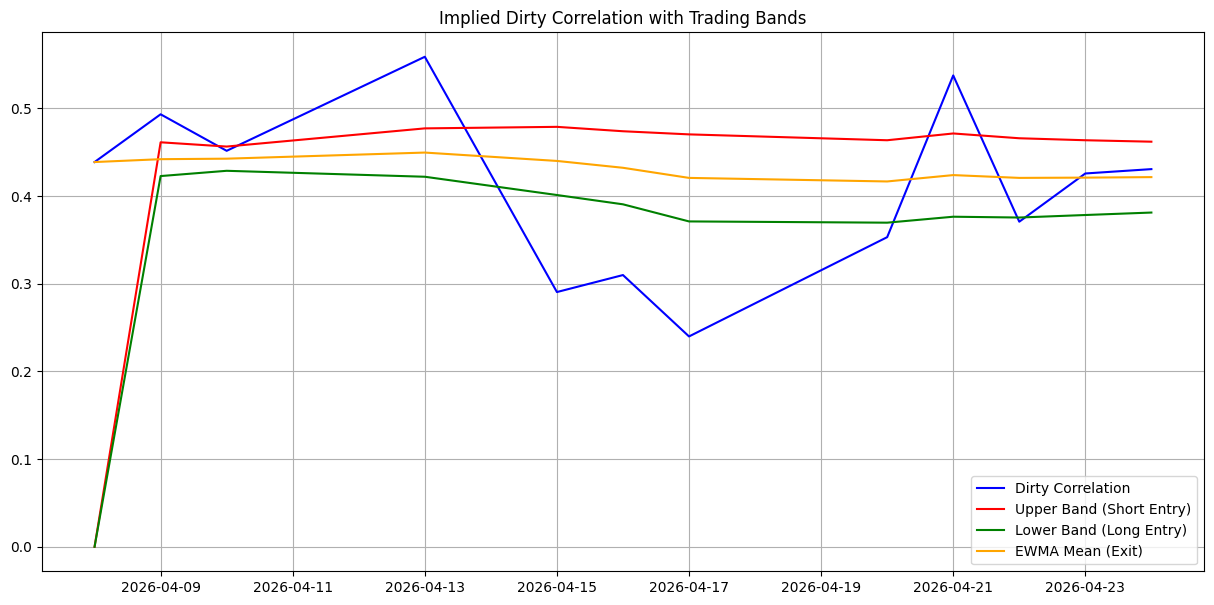

In [10]:
plt.figure(figsize=(15, 7))
plt.plot(corr_df.index, corr_df['dirty_corr'], label='Dirty Correlation', color='blue')
plt.plot(corr_df.index, corr_df['upper_band'], label='Upper Band (Short Entry)', color='red')
plt.plot(corr_df.index, corr_df['lower_band'], label='Lower Band (Long Entry)', color='green')
plt.plot(corr_df.index, corr_df['moving_average'], label='EWMA Mean (Exit)', color='orange')

plt.title('Implied Dirty Correlation with Trading Bands')
plt.legend(loc='best')
plt.grid(True)

plt.show()

In [11]:
def strategy_pnl(opt_df, signal_df, inverse=False):
    merged = pd.merge(opt_df, signal_df[['positions']], left_on='Date', right_index=True, how='left')
    mult = -1 if inverse else 1
    merged['strategy_PNL'] = merged.positions * mult * merged.daily_straddle_pnl
    return merged

NSEBANK_Opt = strategy_pnl(NSEBANK_Opt, corr_df)
results = {s: strategy_pnl(ticker_dfs[s], corr_df, inverse=True).groupby('Date')['strategy_PNL'].sum() for s in symbols[:-1]}
results['NSEBANK'] = NSEBANK_Opt.groupby('Date')['strategy_PNL'].sum()

total_pnl = (results['HDFCB'] * HDFCB_Lot_Size * HDFCB_Wt +
             results['SBIN'] * SBIN_Lot_Size * SBIN_Wt +
             results['AXSB'] * AXSB_Lot_Size * AXSB_Wt +
             results['KMB'] * KMB_Lot_Size * KMB_Wt +
             results['ICICI'] * ICICI_Lot_Size * ICICI_Wt +
             results['NSEBANK'] * NSEBANK_Lot_Size * NSEBANK_Wt)


In [12]:
print (total_pnl)

Date
2026-04-08       0.0000
2026-04-09    2000.4775
2026-04-10   -1059.5150
2026-04-13    8106.9650
2026-04-15    4503.3650
2026-04-16   -1093.6800
2026-04-17    3654.4150
2026-04-20    2073.7750
2026-04-21    1229.4100
2026-04-22     892.1150
2026-04-23       0.0000
2026-04-24       0.0000
Name: strategy_PNL, dtype: float64


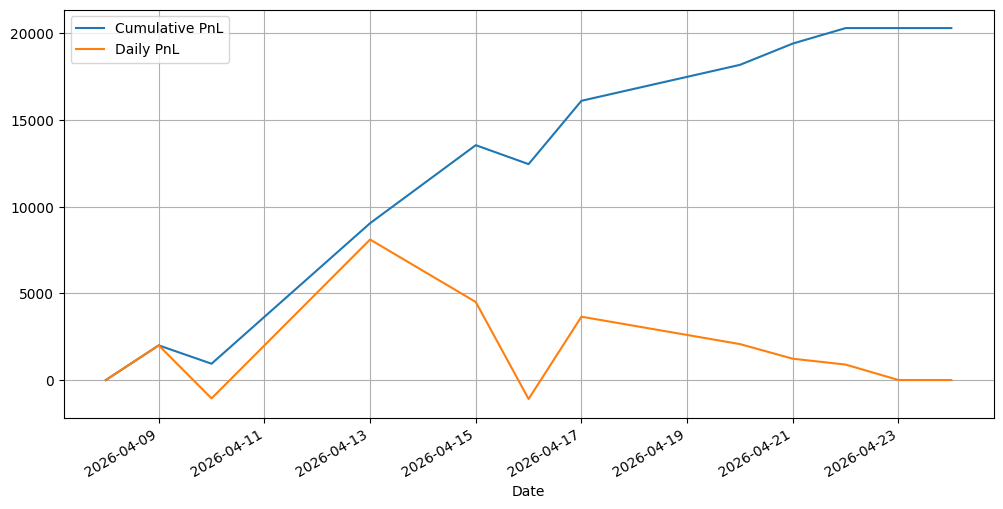

In [13]:
total_pnl.cumsum().plot(figsize=(12, 6), grid=True, label="Cumulative PnL")
total_pnl.plot(figsize=(12, 6), grid=True, label="Daily PnL")
plt.legend(loc='best')

plt.show()